In [4]:
# 뉴스기사 요약하기(Abstractive or Extractive Summary)

In [5]:
# 1 환경 구축 및 데이터 준비

In [18]:
!pip install --upgrade summa

In [19]:
!pip install --upgrade nltk

In [20]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.10.3
2.14.0
3.0.5
1.2.0


In [21]:
import urllib.request # data 불러오기
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [22]:
data.sample(10) # data 확인

,headlines,text
90601,75% doctors have faced violence in workplace: ...,More than 75% doctors have faced physical or v...
82597,Jacqueline Fernandez shares photo from magazin...,Actress Jacqueline Fernandez took to social me...
6084,Criminals are cancelling own bail and surrende...,Uttar Pradesh Director General of Police (DGP)...
87339,Would be insane to compete with 20-21 yr olds:...,"Talking about competition in Bollywood, Katrin..."
29122,Pak batsman made to do push-ups after false sh...,Pakistani batsman Fakhar Zaman was forced to d...
27825,"12 Sikhs, Hindus among 19 killed in Afghan sui...",As many as 12 Sikhs and Hindus were among the ...
40500,IIM Rohtak director booked for sexual harassme...,"The Director of IIM Rohtak, Professor Dheeraj ..."
24469,My next target is to end prostitution in Delhi...,Delhi Commission for Women (DCW) chief Swati M...
79867,Nagaland CM fails to come up for floor test,Nagaland CM Shurhozelie Liezietsu and nine oth...
16007,Jawan martyred in Kashmir was part of 2016 sur...,"Lance Naik Sandeep Singh, who was martyred on ..."


In [11]:
# 2 데이터 확인 및 전처리 준비

In [23]:
print(data.columns) # 열 이름 확인
print('데이터 개수 :', len(data))
print(data.isnull().sum())  # 결측치 확인

Index(['headlines', 'text'], dtype='str')
데이터 개수 : 98401
headlines    0
text         0
dtype: int64


In [24]:
data.drop_duplicates(subset=['text'], inplace=True) #중복 데이터 제거
print(len(data))

98360


In [25]:
# 본문/요약 길이 분포 확인 (나중에 max_len 정할 때 참고용-같은 batch 내에 패딩 얼마나 넣을 건가)

In [26]:
text_len = data['text'].apply(lambda x: len(x.split()))
headlines_len = data['headlines'].apply(lambda x: len(x.split()))

print('본문 길이 - 최소/최대/평균:', text_len.min(), text_len.max(), round(text_len.mean(), 1))
print('요약 길이 - 최소/최대/평균:', headlines_len.min(), headlines_len.max(), round(headlines_len.mean(), 1))

본문 길이 - 최소/최대/평균: 1 91 58.2
요약 길이 - 최소/최대/평균: 1 18 9.6


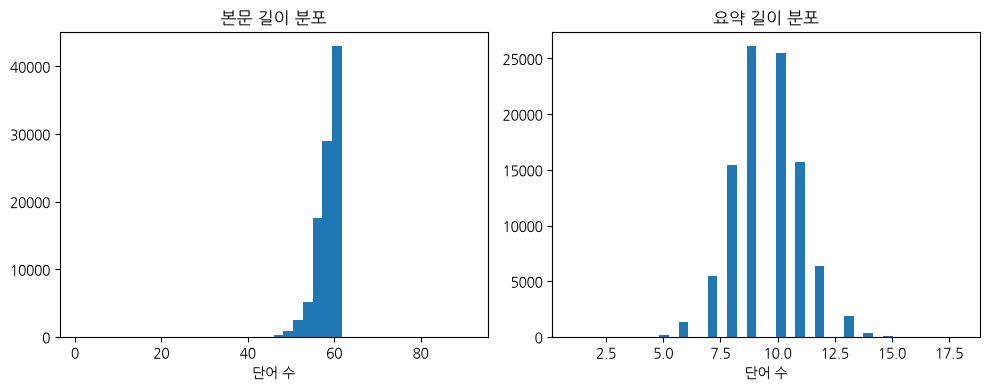

In [27]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(text_len, bins=40) # 패딩 길이 정하기 위해 text 길이 측정
plt.title('본문 길이 분포')
plt.xlabel('단어 수')

plt.subplot(1,2,2)
plt.hist(headlines_len, bins=40) # 패딩 길이 정하기 위해 headline 길이 측정
plt.title('요약 길이 분포')
plt.xlabel('단어 수')

plt.tight_layout()
plt.show()

In [ ]:
# 본문의 70~80% 이상이 커버되는 길이, 요약은 대부분이 커버되는 길이를 고르기
가장 긴 문장길이 이상치로 잡으면 문장이 내용보다 훨씬 긴 패딩으로 채워짐
전체 데이터 중 몇 퍼센트가 이 길이 내에 들어오는지를 기준으로 잡고

이상치(너무 긴 문장)는 아예 제외 or 잘라내고,
대다수의 문장들 중 손실 없이 담을 수 있는 효율적인 지점을 찾는 것.

In [ ]:
# 전처리

In [29]:
import re
from bs4 import BeautifulSoup

contractions = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot", "'cause": "because",
    "could've": "could have", "couldn't": "could not", "didn't": "did not",
    "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will", "he's": "he is",
    "how'd": "how did", "how'll": "how will", "how's": "how is", "i'd": "i would",
    "i'll": "i will", "i'm": "i am", "i've": "i have", "isn't": "is not",
    "it'd": "it would", "it'll": "it will", "it's": "it is", "let's": "let us",
    "should've": "should have", "shouldn't": "should not", "that's": "that is",
    "there's": "there is", "they'd": "they would", "they'll": "they will",
    "they're": "they are", "they've": "they have", "wasn't": "was not",
    "we'd": "we would", "we'll": "we will", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are", "you've": "you have"
}

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords') #영어 불용목록 다운로드
stop_words = set(stopwords.words('english'))

def clean_text(text, remove_stopwords=False):
    text = text.lower() #소문자 통일
    text = BeautifulSoup(text, "lxml").text #html 태그 제거
    text = re.sub(r'\([^)]*\)', '', text) #괄호, 안의 내용 제거
    text = re.sub('"', '', text) #큰따옴표 제거
    text = ' '.join([contractions[t] if t in contractions else t for t in text.split(" ")])
    text = re.sub(r"'s\b", "", text) #소유격 's 제거
    text = re.sub("[^a-zA-Z]", " ", text) #숫자, 특수문자 제거
    text = re.sub('[m]{2,}', 'mm', text) #노이즈성 반복 표현 정규화

    if remove_stopwords: #문장을 단어 단위로 쪼개서 하나씩 확인
        tokens = [w for w in text.split() if w not in stop_words and len(w) > 1] #불용어 아닌 단어, 길이가 2글자 이상이여야 통과
    else:
        tokens = [w for w in text.split() if len(w) > 1] #단어 길이가 2글자 이상이면 통과
    return ' '.join(tokens).strip()

[nltk_data] Downloading package stopwords to /Users/sooah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
clean_text_list = [clean_text(t, remove_stopwords=True) for t in data['text']] #본문-인코더 역할
clean_headlines_list = [clean_text(t, remove_stopwords=False) for t in data['headlines']] #요약-디코더가 생성하는 정답

data['text'] = clean_text_list #정제된 결과로 기존 컬럼 덮어쓰기
data['headlines'] = clean_headlines_list

# 정제 후 빈 문자열이 된 행 제거
data['text'].replace('', pd.NA, inplace=True)
data['headlines'].replace('', pd.NA, inplace=True)
data.dropna(axis=0, inplace=True)
print('정제 후 샘플 수:', len(data))

data.sample(5)

정제 후 샘플 수: 98360


/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_41296/933074100.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['text'].replace('', pd.NA, inplace=True)
/var/folders/z_/64y20xy111n7gy3bp9tvq97c0000gn/T/ipykernel_41296/933074100.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series t

,headlines,text
65231,labourers fall to death from under constructio...,three labourers killed one injured fell constr...
76729,terror threat very high as is fighters return ...,many jihadists returned france war zones iraq ...
77512,what gifts did pm narendra modi take home this...,pm narendra modi took wristwatch british compa...
15293,cash strapped il fs with cr debt to raise cr,shareholders infrastructure leasing financial ...
95291,govt trying to find middle path on highway liq...,union culture tourism minister mahesh sharma m...


In [ ]:
# 디코더 입력/타겟에 시작, 종료 토큰 추가(sos, eos from seq2seq)

In [31]:
data['decoder_input'] = data['headlines'].apply(lambda x: 'sostoken ' + x) #sos 토큰: 생성 시작

data['decoder_target'] = data['headlines'].apply(lambda x: x + ' eostoken') #eos 토큰: 종료

print(data[['headlines', 'decoder_input', 'decoder_target']].sample(3))

                                               headlines  \
52427  touching girl breast is childhood stuff actor ...   
15130  un chief antonio guterres pays tribute to maha...   
5607   not alliance opinion akhilesh on rahul for pm ...   

                                           decoder_input  \
52427  sostoken touching girl breast is childhood stu...   
15130  sostoken un chief antonio guterres pays tribut...   
5607   sostoken not alliance opinion akhilesh on rahu...   

                                          decoder_target  
52427  touching girl breast is childhood stuff actor ...  
15130  un chief antonio guterres pays tribute to maha...  
5607   not alliance opinion akhilesh on rahul for pm ...  


In [ ]:
# 길이 확인 및 최대 길이 결정하기

In [32]:
import numpy as np

text_len = data['text'].apply(lambda x: len(x.split()))
headlines_len = data['decoder_input'].apply(lambda x: len(x.split()))  # sostoken 포함 기준으로 재계산

print('본문 길이 - 최소/최대/평균:', text_len.min(), text_len.max(), round(text_len.mean(), 1))
print('요약 길이 - 최소/최대/평균:', headlines_len.min(), headlines_len.max(), round(headlines_len.mean(), 1))

본문 길이 - 최소/최대/평균: 1 60 35.1
요약 길이 - 최소/최대/평균: 2 17 10.3


In [33]:
def coverage_check(lengths, max_len): # 커버리지 확인 함수(max_len 이하 문서 비율 확인)
    return sum(1 for l in lengths if l <= max_len) / len(lengths) * 100

print('\n[본문 길이별 커버리지]')
for ml in [30, 40, 50, 60, 70, 80]:
    print(f"max_len={ml} → 커버리지 {coverage_check(text_len, ml):.1f}%")

print('\n[요약 길이별 커버리지]')
for ml in [8, 10, 12, 14, 16, 18]:
    print(f"max_len={ml} → 커버리지 {coverage_check(headlines_len, ml):.1f}%")


[본문 길이별 커버리지]
max_len=30 → 커버리지 11.2%
max_len=40 → 커버리지 92.4%
max_len=50 → 커버리지 100.0%
max_len=60 → 커버리지 100.0%
max_len=70 → 커버리지 100.0%
max_len=80 → 커버리지 100.0%

[요약 길이별 커버리지]
max_len=8 → 커버리지 8.9%
max_len=10 → 커버리지 56.7%
max_len=12 → 커버리지 94.5%
max_len=14 → 커버리지 99.8%
max_len=16 → 커버리지 100.0%
max_len=18 → 커버리지 100.0%


In [34]:
text_max_len = 50       #본문 80~90% 안팎
headlines_max_len = 13  #요약 95% 이상

In [35]:
mask = (data['text'].apply(lambda x: len(x.split())) <= text_max_len) & \
       (data['decoder_input'].apply(lambda x: len(x.split())) <= headlines_max_len)
#본문/요약 둘 다 최대길이 이내인 샘플만 남김 (이상치는 제외)
data = data[mask]
print('길이 필터링 후 샘플 수:', len(data))

길이 필터링 후 샘플 수: 97175


In [ ]:
# 데이터셋 분리(train/test)

In [36]:
from sklearn.model_selection import train_test_split

encoder_input = data['text'].values
decoder_input = data['decoder_input'].values
decoder_target = data['decoder_target'].values

encoder_input_train, encoder_input_test, \
decoder_input_train, decoder_input_test, \
decoder_target_train, decoder_target_test = train_test_split(
    encoder_input, decoder_input, decoder_target,
    test_size=0.2, random_state=42
)

print('훈련 데이터 크기:', len(encoder_input_train))
print('테스트 데이터 크기:', len(encoder_input_test))

훈련 데이터 크기: 77740
테스트 데이터 크기: 19435


In [ ]:
# 본문 토큰화 및 인코딩

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer

src_tokenizer = Tokenizer() # 토크나이저 학습시키기-단어별 등장 빈도 파악
src_tokenizer.fit_on_texts(encoder_input_train)

threshold = 7 # 등장 빈도가 낮은 단어 얼마나 되는지 전체에서 확인(등장 빈도 낮은 단어->학습 샘플이 부족-> 좋은 임베딩을 만들기 어려움->어휘사전에서 제외함)
total_cnt = len(src_tokenizer.word_index)  # 전체 단어 수
rare_cnt = sum(1 for _, cnt in src_tokenizer.word_counts.items() if cnt < threshold)

print(f"본문 전체 단어 수: {total_cnt}")
print(f"등장 빈도 {threshold}회 미만인 희귀 단어 수: {rare_cnt} ({rare_cnt/total_cnt*100:.1f}%)")

src_vocab = total_cnt - rare_cnt + 1 #빈도 낮은 단어 제외한 어휘 크기 결정, +1은 (0번 인덱스를 위함)
print(f"실제 사용할 본문 어휘 크기: {src_vocab}")

본문 전체 단어 수: 69317
등장 빈도 7회 미만인 희귀 단어 수: 47250 (68.2%)
실제 사용할 본문 어휘 크기: 22068


In [ ]:
# 요약 토크나이저

In [38]:
tar_tokenizer = Tokenizer() # decoder_input을 기준으로 토크나이저 학습 (sos, eos 포함)
tar_tokenizer.fit_on_texts(list(decoder_input_train) + list(decoder_target_train))

threshold = 6
total_cnt = len(tar_tokenizer.word_index)
rare_cnt = sum(1 for _, cnt in tar_tokenizer.word_counts.items() if cnt < threshold)

print(f"요약 전체 단어 수: {total_cnt}")
print(f"등장 빈도 {threshold}회 미만인 희귀 단어 수: {rare_cnt} ({rare_cnt/total_cnt*100:.1f}%)")

tar_vocab = total_cnt - rare_cnt + 1
print(f"실제 사용할 요약 어휘 크기: {tar_vocab}")

요약 전체 단어 수: 30042
등장 빈도 6회 미만인 희귀 단어 수: 14637 (48.7%)
실제 사용할 요약 어휘 크기: 15406


In [ ]:
# 확정된 어휘 크기로 토크나이저(어휘 사전 만들고, 문장을 숫자 시퀀스로 바꾸기)

In [39]:
src_tokenizer = Tokenizer(num_words=src_vocab, oov_token='UNK')# OOV는 UNK 토큰으로 처리
src_tokenizer.fit_on_texts(encoder_input_train)

encoder_input_train = src_tokenizer.texts_to_sequences(encoder_input_train)
encoder_input_test = src_tokenizer.texts_to_sequences(encoder_input_test)

tar_tokenizer = Tokenizer(num_words=tar_vocab, oov_token='UNK')
tar_tokenizer.fit_on_texts(decoder_input_train)

decoder_input_train = tar_tokenizer.texts_to_sequences(decoder_input_train)
decoder_target_train = tar_tokenizer.texts_to_sequences(decoder_target_train)
decoder_input_test = tar_tokenizer.texts_to_sequences(decoder_input_test)
decoder_target_test = tar_tokenizer.texts_to_sequences(decoder_target_test)

print(encoder_input_train[0][:10])
print(decoder_input_train[0])

[520, 139, 974, 179, 3982, 381, 15288, 1571, 282, 300]
[2, 634, 198, 7, 395, 6, 113, 10401, 1935, 4, 95, 2622]


In [ ]:
# 패딩작업

In [40]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

encoder_input_train = pad_sequences(encoder_input_train, maxlen=text_max_len, padding='post') #문장 뒤에 0 채움
encoder_input_test = pad_sequences(encoder_input_test, maxlen=text_max_len, padding='post')

decoder_input_train = pad_sequences(decoder_input_train, maxlen=headlines_max_len, padding='post')
decoder_target_train = pad_sequences(decoder_target_train, maxlen=headlines_max_len, padding='post')
decoder_input_test = pad_sequences(decoder_input_test, maxlen=headlines_max_len, padding='post')
decoder_target_test = pad_sequences(decoder_target_test, maxlen=headlines_max_len, padding='post')

print("encoder_input_train shape:", encoder_input_train.shape) # 패딩 완료
print("decoder_input_train shape:", decoder_input_train.shape) # 학습 트레인된 수, 한 문장의 표현된 수

encoder_input_train shape: (77740, 50)
decoder_input_train shape: (77740, 13)


In [ ]:
# 3. 모델 설계

In [41]:
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [42]:
embedding_dim = 128   # 각 단어를 표현할 벡터의 차원 수
hidden_size = 256     # LSTM의 hidden state 크기

print(src_vocab) #본문 어휘 크기
print(tar_vocab) #요약 어휘 크기
print(text_max_len) #본문 최대 길이
print(headlines_max_len) #요약 최대 길이

22068
15406
50
13


In [ ]:
# 인코더 구축

In [43]:
# 인코더 입력: (배치, text_max_len) 크기의 정수 시퀀스
encoder_inputs = Input(shape=(text_max_len,))

# 임베딩 층: 정수 인덱스를 embedding_dim 크기의 밀집 벡터로 변환
enc_emb = Embedding(src_vocab, embedding_dim)(encoder_inputs)

# 인코더 LSTM 1층
encoder_lstm1 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

# 인코더 LSTM 2층 (층을 쌓으면 더 복잡한 패턴 학습 가능)
encoder_lstm2 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

# 인코더 LSTM 3층 (최종 층) - return_sequences=True로 모든 타임스텝의 출력을 보존
# 이게 바로 Attention이 "참고할 모든 hidden state"가 됨
encoder_lstm3 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
encoder_outputs, state_h, state_c = encoder_lstm3(encoder_output2)

In [ ]:
# return_sequences=True는 마지막 hidden state 하나만 주는 게 아니라, 매 타임의 스텝마다 hidden state를 전부 반환
[Attention이 인코더의 모든 hidden state를 다시 들여다봄] hidden state가 위의 encoder_outputs이다.

In [ ]:
# 디코더 

In [44]:
decoder_inputs = Input(shape=(headlines_max_len,))

dec_emb_layer = Embedding(tar_vocab, embedding_dim)
dec_emb = dec_emb_layer(decoder_inputs)

# 디코더 LSTM - 인코더의 마지막 상태(state_h, state_c)를 초기 상태로 받아서 시작
decoder_lstm = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=[state_h, state_c])

In [ ]:
# Attention층 추가

In [45]:
from tensorflow.keras.layers import AdditiveAttention

# 디코더의 각 시점 출력이 인코더의 모든 시점 출력(encoder_outputs)을 참고하도록 함
attn_layer = AdditiveAttention(name='attention_layer')
attn_out = attn_layer([decoder_outputs, encoder_outputs])

# 디코더 자체 출력 + attention으로 얻은 정보를 이어붙임(concatenate)
decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])

In [ ]:
# 마지막 출력층

In [46]:
# 어휘사전 크기만큼의 확률 분포를 출력 (다음 단어가 무엇일지 예측)
decoder_softmax_layer = TimeDistributed(Dense(tar_vocab, activation='softmax'))
decoder_softmax_outputs = decoder_softmax_layer(decoder_concat_input)

# 최종 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_softmax_outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 128)   │  2,824,704 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 50, 256), │    394,240 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm[0][0]        │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 13, 128)   │  1,971,968 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 50, 256), │    525,312 │ lstm_1[0][0]      │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 13, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm_2[0][1],     │
│                     │ (None, 256)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 13, 256)   │        256 │ lstm_3[0][0],     │
│ (AdditiveAttention) │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_layer        │ (None, 13, 512)   │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 13, 15406) │  7,903,278 │ concat_layer[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,539,310 (55.46 MB)

 Trainable params: 14,539,310 (55.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 
임베딩 층 2개 (인코더+디코더) -> 파라미터 비중 약 480만 개 (33%)
LSTM 4층 (인코더 3 + 디코더 1)	-> 파라미터 비중 약 180만 개 (12%)
Attention	-> 파라미터 비중 256개 (거의 0%) [타임 스텝에 관계 없이 딱 하나의 계산 규칙만 배우면 됨-가중치 자체 작아도 충분함]
최종 출력층 -> 파라미터 비중	약 790만 개 (54%)

총 파라미터 14,539,310 
트레인 받은 파라미터도 14,539,310

In [ ]:
# 모델 컴파일하기

In [47]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')

In [ ]:
# 정답 레이블 decoder_target이 원핫벡터가 아닌 정수 인덱스를 써서 'sparse_categorical_crossentropy'를 쓴다
원-핫이면 categorical_crossentropy를 썼겠지만, 현 pad-sequences로 만든 정수 배열이니 sparse가 맞다. 
rmsprop는 seq2seq에서 많이 쓰는 옵티마이저
학습 과정에서 옵티마이저 
1) 모델이 예측함 (forward pass)
2) 예측값과 정답을 비교해서 손실(loss) 계산
3) 손실을 각 가중치에 대해 미분 → 기울기(gradient) 계산 (backpropagation)
4) 옵티마이저가 이 기울기를 보고 "가중치를 얼마나, 어느 방향으로 바꿀지" 결정  ← 여기가 옵티마이저의 역할
5) 가중치 업데이트
6) 반복

In [ ]:
# 조기 종료 설정

In [48]:
es = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

In [ ]:
# monitor='val_loss' 손실을 지켜본다는 의미
patience=2 손실이 2번 연속 개선되지 않으면 학습을 중단함 → 과적합 방지를 위한 안전장치.
train loss와 validation loss의 간격이 벌어지기 시작하면 자동으로 멈춰줌.

In [49]:
history = model.fit(
    x=[encoder_input_train, decoder_input_train],
    y=decoder_target_train,
    validation_data=([encoder_input_test, decoder_input_test], decoder_target_test),
    batch_size=256,
    epochs=50,
    callbacks=[es]
)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - loss: 5.8010 - val_loss: 5.4837
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - loss: 5.5299 - val_loss: 5.4339
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 582s 2s/step - loss: 5.4663 - val_loss: 5.3604
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - loss: 5.3777 - val_loss: 5.2456
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - loss: 5.2537 - val_loss: 5.1439
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - loss: 5.1648 - val_loss: 5.0691
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - loss: 5.0874 - val_loss: 5.0022
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - loss: 5.0116 - val_loss: 4.9139
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - loss: 4.9149 - val_loss: 4.8290
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - loss: 4.8248 - val_loss: 4.7467
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - loss: 4.7424 - val_loss: 4.6747
Epoch 12/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# 소요시간 7시간 50분 

In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('학습 과정에서의 Loss 변화 (eostoken 포함')
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# 4 인덱스-> 단어 사전 변환 준비

In [52]:
src_index_to_word = src_tokenizer.index_word
tar_index_to_word = tar_tokenizer.index_word
tar_word_to_index = tar_tokenizer.word_index

In [55]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate

# --- 인코더 추론 모델 ---
# 학습 때 만든 encoder_inputs, encoder_outputs(모든 시점의 hidden state), 
# state_h, state_c(마지막 시점 상태)를 그대로 재사용해서
# "입력 문장 -> hidden state 전체 + 마지막 상태"를 뽑아내는 모델로 재조립
encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

# --- 디코더 추론 모델 준비 ---
# 학습 때는 decoder_input 전체를 한번에 넣고 병렬로 계산했지만,
# 실제 예측(추론) 시에는 디코더가 "한 단어씩" 순차적으로 생성하면서
# 매 스텝 이전 상태(h, c)를 직접 넘겨받아야 하므로 입력 형태를 새로 정의함

# 이전 스텝의 hidden state(h), cell state(c)를 입력으로 받을 자리
decoder_state_input_h = Input(shape=(hidden_size,))
decoder_state_input_c = Input(shape=(hidden_size,))

# Attention이 참고할 "인코더의 모든 시점 hidden state"를 입력으로 받을 자리
# (학습 때는 encoder_outputs를 내부에서 바로 연결했지만,
#  추론 때는 인코더 모델과 디코더 모델이 분리되어 있으므로 외부에서 값을 넣어줘야 함)
decoder_hidden_state_input = Input(shape=(text_max_len, hidden_size))

# 학습 때 썼던 임베딩 레이어(dec_emb_layer)를 그대로 재사용
# -> 새로 학습하지 않고, 이미 학습된 가중치를 그대로 가져다 쓰는 것이 핵심
dec_emb2 = dec_emb_layer(decoder_inputs)

# 학습 때 썼던 decoder_lstm 레이어를 그대로 재사용
# 다만 초기 상태(initial_state)는 매 스텝 새로 입력받은 h, c로 지정
# (학습 때는 인코더의 최종 상태로 한 번만 초기화했지만,
#  추론 때는 매 단어 생성마다 상태를 갱신하며 이어가야 하므로 외부에서 주입)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c]
)

# 학습 때 썼던 attn_layer(Attention)를 그대로 재사용
# 지금 디코더의 출력(Query 역할)과, 외부에서 입력받은 인코더의 전체 hidden state(Key/Value 역할)를 비교해서
# 이번 스텝에 맞는 context vector(attn_out_inf)를 계산
attn_out_inf = attn_layer([decoder_outputs2, decoder_hidden_state_input])

# 디코더 자체 출력 + Attention으로 얻은 context vector를 이어붙임 (학습 때와 동일한 구조)
decoder_inf_concat = Concatenate(axis=-1)([decoder_outputs2, attn_out_inf])

# 학습 때 썼던 출력층(decoder_softmax_layer)을 그대로 재사용해서
# 다음 단어의 확률 분포(어휘사전 크기만큼)를 계산
decoder_outputs2 = decoder_softmax_layer(decoder_inf_concat)

# --- 최종 디코더 추론 모델 정의 ---
# 입력: [지금 넣을 단어 하나, 인코더 전체 hidden state, 이전 h, 이전 c]
# 출력: [다음 단어의 확률 분포, 갱신된 h, 갱신된 c]
# -> 이 출력된 h, c를 다시 다음 스텝의 입력으로 재사용하면서 한 단어씩 반복 생성하게 됨
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)

In [ ]:
# 요약 생성함수

In [56]:
import numpy as np

def decode_sequence(input_seq):
    # 1. 입력 문장을 인코딩해서, 모든 hidden state + 마지막 상태를 얻음
    e_out, e_h, e_c = encoder_model.predict(input_seq, verbose=0)

    # 2. 디코더의 첫 입력 = sostoken
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False # 종료 여부를 관리하는 플래그
    decoded_sentence = '' # 생성된 단어들을 순서대로 담을 리스트

    while not stop_condition: # 3. 한 단어씩 반복 생성 (eostoken을 만나거나 최대 길이에 도달할 때까지)
        output_tokens, h, c = decoder_model.predict([target_seq, e_out, e_h, e_c], verbose=0)

        # 가장 확률 높은 단어 인덱스 선택
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = tar_index_to_word.get(sampled_token_index, '')

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: eostoken을 만나거나 최대 길이 도달
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (headlines_max_len - 1):
            stop_condition = True

        # 다음 스텝을 위해 target_seq, 상태 갱신
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        e_h, e_c = h, c

    return decoded_sentence.strip() # 생성된 단어들을 공백으로 이어붙여서 하나의 문장으로 반환

In [60]:
def seq_to_text(input_seq):
    # 정수 인덱스 배열(input_seq)을 실제 단어로 하나씩 변환해서 문장으로 복원
    # i != 0 조건: 0은 패딩 값이므로 결과에서 제외
    return ' '.join([src_index_to_word[i] for i in input_seq if i != 0])

def seq_to_headline(input_seq):
    result = []
    for i in input_seq:
        # 패딩(0)은 건너뜀
        if i == 0:
            continue
        # 인덱스를 단어로 변환 (사전에 없으면 빈 문자열)
        word = tar_index_to_word.get(i, '')
        # sostoken, eostoken, 빈 문자열은 실제 내용이 아니므로 결과에서 제외
        # (사람이 읽을 요약문에는 시작/종료 표시가 필요 없기 때문)
        if word in ('sostoken', 'eostoken', ''):
            continue
        result.append(word)
    return ' '.join(result)

In [59]:
# 테스트 데이터 중 5개 샘플을 뽑아서 원문 / 실제 요약 / 모델 예측 요약을 나란히 비교
for i in [10, 55, 120, 300, 777]:
    print("원문 :", seq_to_text(encoder_input_test[i]))
    print("실제 요약 :", seq_to_headline(decoder_input_test[i]))
    print("예측 요약 :", decode_sequence(encoder_input_test[i].reshape(1, text_max_len)))
    print("\n")

원문 : spanish tennis player rafael nadal became first player open era win single grand slam title ten times winning th french open sunday nadal playing nd grand slam final defeated stan UNK th grand slam title nadal career record roland UNK reads wins two losses
실제 요약 : nadal first in open era to win single grand slam times
예측 요약 : nadal beats nadal to win th grand slam title UNK UNK UNK


원문 : chief justice india js khehar monday slammed senior advocates defending abuse judiciary institution everybody abuses us abuse us people wrongfully abuse us never stand us asserted justice khehar made remarks hearing contempt case advocate accused court fixing cases
실제 요약 : cji slams lawyers for defending those who abuse judiciary
예측 요약 : judge judge quits over UNK of us judge judge UNK UNK UNK


원문 : one year old toddler died saturday fell bucket water drowned home delhi incident took place boy mother sleeping father cousin boy playing glass fell bucket drowned trying retrieve police said
실제 요약 :

In [ ]:
# epoch 20번 늘려보기

In [61]:
# 기존에 학습된 model 객체를 그대로 이어받아서 추가로 20 에폭 더 학습시킴
# (모델을 새로 만들지 않고, 지금까지 학습된 가중치에서 이어서 진행됨)
history2 = model.fit(
    x=[encoder_input_train, decoder_input_train],      # 인코더 입력, 디코더 입력을 함께 전달
    y=decoder_target_train,                              # 정답: 한 스텝씩 밀린 디코더 타겟
    validation_data=([encoder_input_test, decoder_input_test], decoder_target_test),  # 검증용 데이터
    batch_size=256,   # 한 번에 256개 샘플씩 묶어서 학습 (기존과 동일하게 유지)
    epochs=20,        # 추가로 20 에폭만큼 더 학습
    callbacks=[es]    # EarlyStopping 콜백 재사용 -> val_loss가 개선 안 되면 중간에 자동 중단
)

Epoch 1/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - loss: 3.3255 - val_loss: 3.7250
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 578s 2s/step - loss: 3.3052 - val_loss: 3.7156
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - loss: 3.2848 - val_loss: 3.7046
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - loss: 3.2651 - val_loss: 3.7015
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - loss: 3.2453 - val_loss: 3.6991
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 575s 2s/step - loss: 3.2264 - val_loss: 3.6801
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - loss: 3.2062 - val_loss: 3.6776
Epoch 8/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - loss: 3.1883 - val_loss: 3.6644
Epoch 9/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - loss: 3.1705 - val_loss: 3.6576
Epoch 10/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 564s 2s/step - loss: 3.1529 - val_loss: 3.6498
Epoch 11/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - loss: 3.1343 - val_loss: 3.6484
Epoch 12/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# 소요시간 3시간 9분

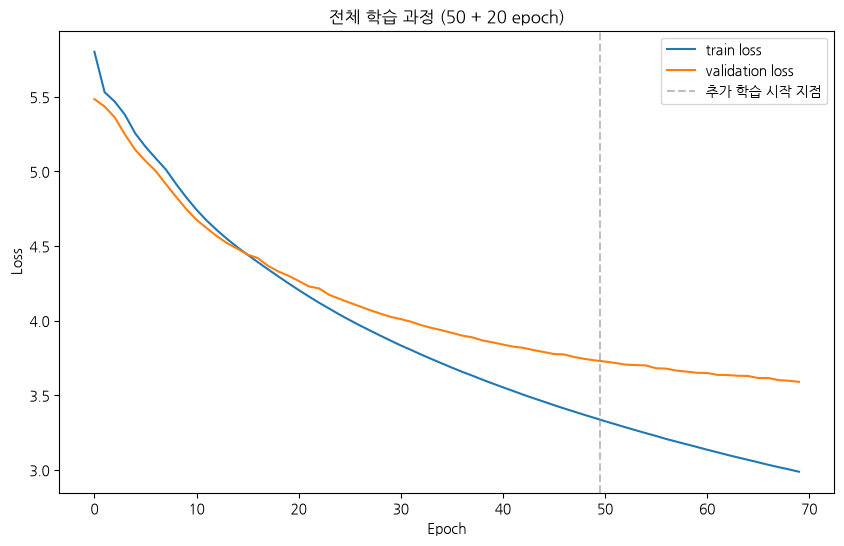

In [62]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 처음 50 에폭 + 추가 20 에폭을 이어붙임
total_train_loss = history.history['loss'] + history2.history['loss']
total_val_loss = history.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(total_train_loss, label='train loss')
plt.plot(total_val_loss, label='validation loss')
plt.axvline(x=49.5, color='gray', linestyle='--', alpha=0.5, label='추가 학습 시작 지점')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('전체 학습 과정 (50 + 20 epoch)')
plt.show()

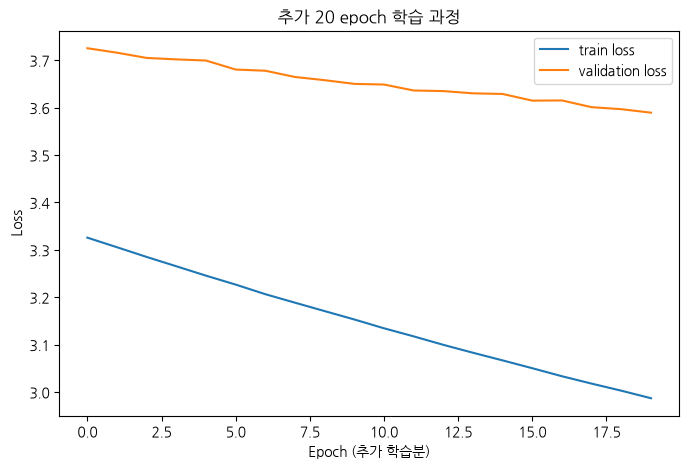

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='validation loss')
plt.xlabel('Epoch (추가 학습분)')
plt.ylabel('Loss')
plt.legend()
plt.title('추가 20 epoch 학습 과정')
plt.show()

In [ ]:
# train data와 val data의 차이
encoder_lstm1 = LSTM(hidden_size, return_sequences=True, return_state=True, dropout=0.4, recurrent_dropout=0.4)

뉴런의 40%를 랜덤하게 끈다.
dropout — '입력 방향'에 적용됨/recurrent_dropout — '시간 방향'에 적용됨

LSTM은 이전 시점의 hidden state를 계속 다음 시점으로 넘겨받으면서 순환하는 구조여서
이 시간을 넘어 순환하는(recurrent) 연결 쪽에도 별도로 40%를 랜덤하게 끄는 것.

monitor='val_loss', patience=2는 val_loss가 2번 연속 개선 안 될 때만 발함.
지금 20 에폭 내내 val_loss가 매번 갱신되고 있으니, EarlyStopping 입장에선 아직 멈출 이유가 없다고 정확하게 판단하고 있는 것.

모델 크기 대비 데이터 양
Total params: 14,539,310개
훈련 샘플: 약 77,740개
파라미터 수가 데이터 양에 비해 상대적으로 크면, 
모델이 일반적인 패턴보다 학습 데이터의 특정 사례들을 기억해버릴 여지가 더 커짐.
이것도 결국 과적합의 한 형태이긴 하지만, 모델 용량 대비 데이터 양이라는 구조적 요인으로 따로 볼 수 있음.

In [65]:
# 인덱스 변환 사전
src_index_to_word = src_tokenizer.index_word
tar_index_to_word = tar_tokenizer.index_word
tar_word_to_index = tar_tokenizer.word_index

In [66]:
# 추론용 인코더/디코더 재조립
from tensorflow.keras.layers import Input, Concatenate
from tensorflow.keras.models import Model

encoder_model = Model(inputs=encoder_inputs, outputs=[encoder_outputs, state_h, state_c])

decoder_state_input_h = Input(shape=(hidden_size,))
decoder_state_input_c = Input(shape=(hidden_size,))
decoder_hidden_state_input = Input(shape=(text_max_len, hidden_size))

dec_emb2 = dec_emb_layer(decoder_inputs)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c]
)

attn_out_inf = attn_layer([decoder_outputs2, decoder_hidden_state_input])
decoder_inf_concat = Concatenate(axis=-1)([decoder_outputs2, attn_out_inf])
decoder_outputs2 = decoder_softmax_layer(decoder_inf_concat)

decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input, decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2]
)

In [70]:
# 요약 생성 함수
import numpy as np

def decode_sequence(input_seq):
    e_out, e_h, e_c = encoder_model.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_words = []

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq, e_out, e_h, e_c], verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = tar_index_to_word.get(sampled_token_index, '')

        if sampled_token == 'eostoken':
            stop_condition = True
        else:
            if sampled_token != '':
                decoded_words.append(sampled_token)
            if len(decoded_words) >= (headlines_max_len - 1):
                stop_condition = True

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        e_h, e_c = h, c

    return ' '.join(decoded_words).strip()

In [68]:
# 텍스트 복원 함수
def seq_to_text(input_seq):
    return ' '.join([src_index_to_word[i] for i in input_seq if i != 0])

def seq_to_headline(input_seq):
    result = []
    for i in input_seq:
        if i == 0:
            continue
        word = tar_index_to_word.get(i, '')
        if word in ('sostoken', 'eostoken', ''):
            continue
        result.append(word)
    return ' '.join(result)

In [71]:
# 추론 요약 결과 비교 - 이전과 동일한 샘플로 비교해서 개선 여부 확인
for i in [10, 55, 120, 300, 777]:
    print("원문 :", seq_to_text(encoder_input_test[i]))
    print("실제 요약 :", seq_to_headline(decoder_input_test[i]))
    print("예측 요약 :", decode_sequence(encoder_input_test[i].reshape(1, text_max_len)))
    print("\n")

원문 : spanish tennis player rafael nadal became first player open era win single grand slam title ten times winning th french open sunday nadal playing nd grand slam final defeated stan UNK th grand slam title nadal career record roland UNK reads wins two losses
실제 요약 : nadal first in open era to win single grand slam times
예측 요약 : nadal beats nadal to win th straight title in atp final UNK


원문 : chief justice india js khehar monday slammed senior advocates defending abuse judiciary institution everybody abuses us abuse us people wrongfully abuse us never stand us asserted justice khehar made remarks hearing contempt case advocate accused court fixing cases
실제 요약 : cji slams lawyers for defending those who abuse judiciary
예측 요약 : judge who cannot be chief if you are not judge on us


원문 : one year old toddler died saturday fell bucket water drowned home delhi incident took place boy mother sleeping father cousin boy playing glass fell bucket drowned trying retrieve police said
실제 요약 : 

In [ ]:
# 개선된 점
unk에서 벗어남
어제: UNK
오늘: judge who cannot be chief if you are not judge on us

히즈불 케이스 — 문장 앞부분 품질 향상
어제: hizbul forces UNK killed in encounter in kashmir UNK UNK UNK UNK
오늘: let hizbul mujahideen terrorists killed in encounter UNK UNK UNK UNK UNK

# 개선되어야 할 점
UNK 꼬리 현상
yr old dies after being hit by falling in delhi UNK UNK
let hizbul mujahideen terrorists killed in encounter UNK UNK UNK UNK UNK
mit develops ai based UNK that can detect user UNK UNK UNK

In [73]:
def clean_prediction(text):
    words = text.split()
    # 연속 UNK가 시작되는 지점부터 잘라내기
    for i in range(len(words) - 1):
        if words[i] == 'UNK' and words[i+1] == 'UNK':
            return ' '.join(words[:i]).strip()
    return text

for i in [10, 55, 120, 300, 777]:
    raw_pred = decode_sequence(encoder_input_test[i].reshape(1, text_max_len))
    print("원문 :", seq_to_text(encoder_input_test[i])[:80], "...")
    print("실제 요약 :", seq_to_headline(decoder_input_test[i]))
    print("예측 요약(정리) :", clean_prediction(raw_pred))
    print("\n")

원문 : spanish tennis player rafael nadal became first player open era win single grand ...
실제 요약 : nadal first in open era to win single grand slam times
예측 요약(정리) : nadal beats nadal to win th straight title in atp final


원문 : chief justice india js khehar monday slammed senior advocates defending abuse ju ...
실제 요약 : cji slams lawyers for defending those who abuse judiciary
예측 요약(정리) : judge who cannot be chief if you are not judge on us


원문 : one year old toddler died saturday fell bucket water drowned home delhi incident ...
실제 요약 : toddler dies after falling in bucket of water in delhi
예측 요약(정리) : yr old dies after being hit by falling in delhi


원문 : phd scholar aligarh muslim university militant outfit hizbul mujahideen commande ...
실제 요약 : phd scholar turned hizbul commander killed in encounter
예측 요약(정리) : let hizbul mujahideen terrorists killed in encounter


원문 : researchers created ai based method transfer facial expressions actions one pers ...
실제 요약 : ai transfers facial 

In [ ]:
# 5 추출 요약 

In [74]:
from summa.summarizer import summarize

raw_data = pd.read_csv('/Users/sooah/Aiffel_EPA/weat/data/news_summary_more.csv', encoding='iso-8859-1')
raw_data = raw_data[['text', 'headlines']]
raw_data.drop_duplicates(subset=['text'], inplace=True)

def extractive_summary(text, ratio=0.3):
    try:
        summary = summarize(text, ratio=ratio)
        if summary.strip() == '':
            summary = summarize(text, ratio=ratio, split=True)
            summary = summary[0] if summary else text
        return summary
    except Exception as e:
        return f"(요약 실패: {e})"

In [75]:
keywords = ['nadal', 'khehar', 'toddler', 'hizbul', 'facial expressions']

for kw in keywords:
    matched = raw_data[raw_data['text'].str.lower().str.contains(kw, na=False)]
    if len(matched) > 0:
        row = matched.iloc[0]
        print("=" * 70)
        print("원문(일부):", row['text'][:200], "...")
        print("\n[실제 요약(headlines)]:", row['headlines'])
        print("\n[추출적 요약(Summa)]:", extractive_summary(row['text']))
        print()

원문(일부): Reacting to Novak Djokovic's win over Rafael Nadal to claim a record seventh Australian Open title, a user tweeted, "Djoker Djemolition." Other users reacted with tweets like, "We're witnessing one of ...

[실제 요약(headlines)]: Djoker Djemolition, tweets user on Djokovic's Aus Open win

[추출적 요약(Summa)]: Reacting to Novak Djokovic's win over Rafael Nadal to claim a record seventh Australian Open title, a user tweeted, "Djoker Djemolition." Other users reacted with tweets like, "We're witnessing one of the all-time great finals performances here, sports fans", and "Take a bow @DjokerNole, Sheer domination throughout the tournament."

원문(일부): Retired SC judge Jasti Chelameswar has said that the closed door meeting of those who run the country with Supreme Court judges must be questioned. In 2017, Chelameswar had written to former Chief Jus ...

[실제 요약(headlines)]: Question closed door meetings of politicians, judges: Retd judge

[추출적 요약(Summa)]: Retired SC judge Jasti Chelameswar ha

In [ ]:
# 원문 / 실제 요약 / 추출적 요약 (한국어 번역)

1. 나달-조코비치 호주오픈
* 원문(일부): 노박 조코비치가 라파엘 나달을 꺾고 호주오픈 통산 7번째 우승을 차지한 것에 반응하며, 한 유저가 "조커의 대해체"라는 트윗을 남겼다. 
다른 유저들도 "우리는 역대 최고의 결승전 명승부 중 하나를 목격하고 있다, 스포츠 팬 여러분" 같은 트윗으로 반응했다.
* 실제 요약: 조커의 대해체, 조코비치의 호주오픈 우승에 유저들이 트윗
* 추출적 요약: 노박 조코비치가 라파엘 나달을 꺾고 호주오픈 통산 7번째 우승을 차지한 것에 반응하며, 
한 유저가 "조커의 대해체"라는 트윗을 남겼다. 다른 유저들도 "우리는 역대 최고의 결승전 명승부 중 하나를 목격하고 있다, 
스포츠 팬 여러분", "고개 숙여 인사해라 @DjokerNole, 대회 내내 완전한 지배력을 보여줬다" 같은 트윗으로 반응했다.

2. 은퇴 판사의 폐쇄 회동 발언
* 원문(일부): 은퇴한 대법관 자스티 첼라메스와르는 나라를 운영하는 이들과 대법관들 간의 비공개 회동이 문제 제기되어야 한다고 말했다. 
2017년, 첼라메스와르는 전 대법원장 JS 케하르에게...
* 실제 요약: 정치인과 판사들의 폐쇄 회동을 문제 삼아야 한다: 은퇴 판사
* 추출적 요약: 은퇴한 대법관 자스티 첼라메스와르는 나라를 운영하는 이들과 대법관들 간의 비공개 회동이 문제 제기되어야 한다고 말했다. 
2017년, 첼라메스와르는 전 대법원장 JS 케하르에게 현직 대법관 NV 라마나와 안드라프라데시 주지사 찬드라바부 나이두 사이의 유착 의혹에 대해 서한을 보낸 바 있다.

3. 구르가온 유아 납치 사건
* 원문(일부): 두 살배기 유아가 화요일 아침 구르가온에서 11살 누나와 집 밖에서 놀던 중 한 여성에게 납치된 것으로 알려졌다. 그 여성은...
* 실제 요약: 구르가온에서 여성에게 납치된 2세 아동, 5시간 만에 구조
* 추출적 요약: 두 살배기 유아가 화요일 아침 구르가온에서 11살 누나와 집 밖에서 놀던 중 한 여성에게 납치된 것으로 알려졌다. 
그 여성은 누군가 안에서 부르고 있다고 누나를 속인 뒤 유아를 자신의 집으로 데려갔다. 한편 경찰은 5시간 만에 유아를 구조하고 그 여성을 체포했다.

4. 히즈불 무자헤딘 대원 체포
* 원문(일부): 경찰이 일요일 잠무카슈미르 키쉬트와르에서 수배 중이던 히즈불 무자헤딘 대원 레야즈 아흐마드를 체포했다. 
소총을 든 사진이 온라인에 유출됐던 아흐마드는...
* 실제 요약: 잠무카슈미르에서 수배 중이던 히즈불 대원 체포
* 추출적 요약: 경찰이 일요일 잠무카슈미르 키쉬트와르에서 수배 중이던 히즈불 무자헤딘 대원 레야즈 아흐마드를 체포했다. 
소총을 든 사진이 온라인에 유출됐던 아흐마드는 스리나가르에서의 무장단체 활동 관련 사건에 연루되어 있었다고 경찰 관계자가 밝혔다. 
그의 이름은 7월 1일 키쉬트와르에서 체포된 그의 동료 두 명을 심문하는 과정에서도 나온 바 있다고 덧붙였다.

5. AI 기반 휠체어 조작 키트
* 원문(일부): 브라질 스타트업 후박스 로보틱스는 인텔과 협력하여, 표정과 제스처로 휠체어를 조작할 수 있는 AI 기반 어댑터 키트 '휠리 7'을 CES에서 시연했다.
* 실제 요약: 얼굴로 휠체어를 조작할 수 있는 AI 키트, CES에서 공개
* 추출적 요약: 브라질 스타트업 후박스 로보틱스는 인텔과 협력하여, 표정과 제스처로 휠체어를 조작할 수 있는 AI 기반 어댑터 키트 '휠리 7'을 
2019년 라스베이거스 소비자 가전 전시회(CES)에서 시연했다. 이 키트는 사용자의 제스처를 자동으로 학습하며 설치에 약 7분이 걸린다. 
모터 달린 휠체어 어디에나 장착 가능하다고 스타트업 측은 밝혔다.

In [76]:
import pandas as pd

comparison_table1 = pd.DataFrame({
    '원문 주제': ['나달 그랜드슬램', 'CJI 발언', '델리 유아 사망', '히즈불 사령관 사살', 'AI 표정 전이'],
    '실제 요약(headlines)': [
        'nadal first in open era to win single grand slam times',
        'cji slams lawyers for defending those who abuse judiciary',
        'toddler dies after falling in bucket of water in delhi',
        'phd scholar turned hizbul commander killed in encounter',
        'ai transfers facial expressions actions of people in videos'
    ],
    '추상적 요약 (Seq2Seq+Attention)': [
        'nadal beats nadal to win th straight title in atp final UNK',
        'judge who cannot be chief if you are not judge on us',
        'yr old dies after being hit by falling in delhi UNK UNK',
        'let hizbul mujahideen terrorists killed in encounter UNK UNK UNK UNK UNK',
        'mit develops ai based UNK that can detect user UNK UNK UNK'
    ],
    '추출적 요약 (Summa)': [
        '(원문 문장 그대로, 완전한 문법)',
        '(원문 문장 그대로, 완전한 문법)',
        '(원문 문장 그대로, 완전한 문법)',
        '(원문 문장 그대로, 완전한 문법)',
        '(원문 문장 그대로, 완전한 문법)'
    ]
})

comparison_table1

,원문 주제,실제 요약(headlines),추상적 요약 (Seq2Seq+Attention),추출적 요약 (Summa)
0,나달 그랜드슬램,nadal first in open era to win single grand sl...,nadal beats nadal to win th straight title in ...,"(원문 문장 그대로, 완전한 문법)"
1,CJI 발언,cji slams lawyers for defending those who abus...,judge who cannot be chief if you are not judge...,"(원문 문장 그대로, 완전한 문법)"
2,델리 유아 사망,toddler dies after falling in bucket of water ...,yr old dies after being hit by falling in delh...,"(원문 문장 그대로, 완전한 문법)"
3,히즈불 사령관 사살,phd scholar turned hizbul commander killed in ...,let hizbul mujahideen terrorists killed in enc...,"(원문 문장 그대로, 완전한 문법)"
4,AI 표정 전이,ai transfers facial expressions actions of peo...,mit develops ai based UNK that can detect user...,"(원문 문장 그대로, 완전한 문법)"


In [ ]:
# 다른 문장을 비교하게된 원인
test set 샘플(encoder_input_test[10])이 원본 데이터의 몇 번째 행이었는지 추적할 방법이 없어서, 
키워드 검색을 했는데 키워드 1개 + 첫 번째 결과 채택이 부정확했기 때문임

In [77]:
comparison_table2 = pd.DataFrame({
    '항목': ['생성 방식', '문법 완성도', '핵심 단어 포함', '요약 길이', '새로운 표현 생성 능력', '종료 처리 안정성'],
    'Abstractive (Seq2Seq+Attention)': [
        '원문에 없던 새로운 문장을 단어 단위로 직접 생성',
        '불완전함. 문장 뒷부분에 UNK가 반복되거나 어색한 구문 발생',
        '부분적. 주제어는 포착하나 세부 사실 왜곡 존재',
        '짧고 간결함 (헤드라인 스타일 지향)',
        '있음 (원문에 없던 조합으로 재구성 가능)',
        '불안정. eostoken 타이밍 학습이 아직 미성숙'
    ],
    'Extractive (Summa)': [
        '원문 문장을 통째로 골라서 그대로 추출',
        '완벽함. 원문 자체가 이미 문법적으로 완성됨',
        '매우 높음. 원문을 그대로 가져오므로 정보 손실 없음',
        '상대적으로 김 (문장 단위 추출이라 압축률 낮음)',
        '없음 (원문 문장만 그대로 사용)',
        '문제 없음. 문장 경계가 원문에서 이미 정해져 있음'
    ]
})

comparison_table2

,항목,Abstractive (Seq2Seq+Attention),Extractive (Summa)
0,생성 방식,원문에 없던 새로운 문장을 단어 단위로 직접 생성,원문 문장을 통째로 골라서 그대로 추출
1,문법 완성도,불완전함. 문장 뒷부분에 UNK가 반복되거나 어색한 구문 발생,완벽함. 원문 자체가 이미 문법적으로 완성됨
2,핵심 단어 포함,부분적. 주제어는 포착하나 세부 사실 왜곡 존재,매우 높음. 원문을 그대로 가져오므로 정보 손실 없음
3,요약 길이,짧고 간결함 (헤드라인 스타일 지향),상대적으로 김 (문장 단위 추출이라 압축률 낮음)
4,새로운 표현 생성 능력,있음 (원문에 없던 조합으로 재구성 가능),없음 (원문 문장만 그대로 사용)
5,종료 처리 안정성,불안정. eostoken 타이밍 학습이 아직 미성숙,문제 없음. 문장 경계가 원문에서 이미 정해져 있음


In [ ]:
# 같은 본문 비교를 위한 역추적

In [10]:
import pandas as pd
from summa.summarizer import summarize

# 1) 원본 데이터 로드
raw_data = pd.read_csv('/Users/sooah/Aiffel_EPA/weat/data/news_summary_more.csv', encoding='iso-8859-1')
raw_data = raw_data[['text', 'headlines']]
raw_data.drop_duplicates(subset=['text'], inplace=True)

# 2) extractive 요약 함수
def extractive_summary(text, ratio=0.3):
    try:
        summary = summarize(text, ratio=ratio)
        if summary.strip() == '':
            summary = summarize(text, ratio=ratio, split=True)
            summary = summary[0] if summary else text
        return summary
    except Exception as e:
        return f"(요약 실패: {e})"

# 3) 5개 기사 정확히 찾기
queries = {
    'nadal': ['nadal', 'ten times', 'roland'],
    'khehar': ['khehar', 'fixing cases', 'abuses us'],
    'toddler': ['bucket', 'drowned', 'retrieve'],
    'hizbul': ['aligarh muslim university', 'kupwara', 'bashir'],
    'facial': ['ai', 'transfer', 'facial']
}

matched_rows = {}
for name, kws in queries.items():
    mask = pd.Series([True] * len(raw_data), index=raw_data.index)
    for kw in kws:
        mask &= raw_data['text'].str.lower().str.contains(kw, na=False)
    matched = raw_data[mask]
    if len(matched) >= 1:
        matched_rows[name] = matched.iloc[0]

# 4) 각 기사에 대해 extractive 요약 생성 + 비교 출력
for name, row in matched_rows.items():
    print("=" * 70)
    print(f"[{name}]")
    print("원문(일부):", row['text'][:150], "...")
    print("\n[실제 요약]:", row['headlines'])
    print("\n[Extractive 요약]:", extractive_summary(row['text']))
    print()

[nadal]
원문(일부): Spanish tennis player Rafael Nadal became the first player in the Open Era to win a single Grand Slam title ten times, winning his 10th French Open on ...

[실제 요약]: Nadal first in Open Era to win a single Grand Slam 10 times

[Extractive 요약]: Spanish tennis player Rafael Nadal became the first player in the Open Era to win a single Grand Slam title ten times, winning his 10th French Open on Sunday. Nadal, playing his 22nd Grand Slam final, defeated Stan Wawrinka 6-2, 6-3, 6-1 for his 15th Grand Slam title. Nadal's career record at Roland Garros reads 79 wins and two losses.

[khehar]
원문(일부): Chief Justice of India JS Khehar on Monday slammed senior advocates for defending those who abuse judiciary and the institution. "Everybody abuses us  ...

[실제 요약]: CJI slams lawyers for defending those who 'abuse judiciary'

[Extractive 요약]: Chief Justice of India JS Khehar on Monday slammed senior advocates for defending those who abuse judiciary and the institution.

[toddler]
원문

In [12]:
import pandas as pd

comparison_data = [
    {
        "샘플": "Nadal",
        "실제 요약": "Nadal first in Open Era to win a single Grand Slam 10 times",
        "Abstractive 예측": "nadal beats nadal to win th straight title in atp final",
        "Extractive 예측": """Spanish tennis player Rafael Nadal became the first player in the Open Era to win a single Grand Slam title ten times, winning his 10th French Open on Sunday. Nadal, playing his 22nd Grand Slam final, defeated Stan Wawrinka 6-2, 6-3, 6-1 for his 15th Grand Slam title. Nadal's career record at Roland Garros reads 79 wins and two losses.""",
        "핵심어 누락(Abstractive)": "Open Era, 10 times",
        "핵심어 누락(Extractive)": "없음",
    },
    {
        "샘플": "Khehar",
        "실제 요약": "CJI slams lawyers for defending those who abuse judiciary",
        "Abstractive 예측": "judge who cannot be chief if you are not judge on us",
        "Extractive 예측": """Chief Justice of India JS Khehar on Monday slammed senior advocates for defending those who abuse judiciary and the institution.""",
        "핵심어 누락(Abstractive)": "abuse, judiciary, lawyers",
        "핵심어 누락(Extractive)": "없음",
    },
    {
        "샘플": "Toddler",
        "실제 요약": "Toddler dies after falling in bucket of water in Delhi",
        "Abstractive 예측": "yr old dies after being hit by falling in delhi",
        "Extractive 예측": """A one-year-old toddler died on Saturday after he fell into a bucket of water and drowned in his home in Delhi. The incident took place when the boys mother was sleeping and his father and cousin were out. The boy was playing with a glass, which fell into the bucket, and he drowned while trying to retrieve it, police said.""",
        "핵심어 누락(Abstractive)": "bucket, water (대신 hit by 왜곡 생성)",
        "핵심어 누락(Extractive)": "없음",
    },
    {
        "샘플": "Hizbul",
        "실제 요약": "PhD scholar-turned-Hizbul commander killed in J&K encounter",
        "Abstractive 예측": "let hizbul mujahideen terrorists killed in encounter",
        "Extractive 예측": """PhD scholar from Aligarh Muslim University and militant outfit Hizbul Mujahideen commander Mannan Bashir Wani was shot dead during an encounter with security forces at Jammu and Kashmir's Kupwara on Thursday. One other militant was also killed during the encounter. The forces have recovered arms and ammunitions from the slain militants possession.""",
        "핵심어 누락(Abstractive)": "PhD scholar, commander",
        "핵심어 누락(Extractive)": "없음",
    },
    {
        "샘플": "Facial",
        "실제 요약": "AI transfers facial expressions, actions of people in videos",
        "Abstractive 예측": "mit develops ai based",
        "Extractive 예측": """Researchers have created an AI-based method to transfer facial expressions and actions of one person onto another in videos. The tool analyses the intricate facial movements of a person and produces the same after recognising similar patterns in another. It can also be used to convert black-and-white films to colour and to create content for virtual reality experiences.""",
        "핵심어 누락(Abstractive)": "facial expressions, transfers (대신 MIT 왜곡 생성)",
        "핵심어 누락(Extractive)": "없음",
    },
]

df_compare = pd.DataFrame(comparison_data)
pd.set_option('display.max_colwidth', None)
df_compare

,샘플,실제 요약,Abstractive 예측,Extractive 예측,핵심어 누락(Abstractive),핵심어 누락(Extractive)
0,Nadal,Nadal first in Open Era to win a single Grand Slam 10 times,nadal beats nadal to win th straight title in atp final,"Spanish tennis player Rafael Nadal became the first player in the Open Era to win a single Grand Slam title ten times, winning his 10th French Open on Sunday. Nadal, playing his 22nd Grand Slam final, defeated Stan Wawrinka 6-2, 6-3, 6-1 for his 15th Grand Slam title. Nadal's career record at Roland Garros reads 79 wins and two losses.","Open Era, 10 times",없음
1,Khehar,CJI slams lawyers for defending those who abuse judiciary,judge who cannot be chief if you are not judge on us,Chief Justice of India JS Khehar on Monday slammed senior advocates for defending those who abuse judiciary and the institution.,"abuse, judiciary, lawyers",없음
2,Toddler,Toddler dies after falling in bucket of water in Delhi,yr old dies after being hit by falling in delhi,"A one-year-old toddler died on Saturday after he fell into a bucket of water and drowned in his home in Delhi. The incident took place when the boys mother was sleeping and his father and cousin were out. The boy was playing with a glass, which fell into the bucket, and he drowned while trying to retrieve it, police said.","bucket, water (대신 hit by 왜곡 생성)",없음
3,Hizbul,PhD scholar-turned-Hizbul commander killed in J&K encounter,let hizbul mujahideen terrorists killed in encounter,PhD scholar from Aligarh Muslim University and militant outfit Hizbul Mujahideen commander Mannan Bashir Wani was shot dead during an encounter with security forces at Jammu and Kashmir's Kupwara on Thursday. One other militant was also killed during the encounter. The forces have recovered arms and ammunitions from the slain militants possession.,"PhD scholar, commander",없음
4,Facial,"AI transfers facial expressions, actions of people in videos",mit develops ai based,Researchers have created an AI-based method to transfer facial expressions and actions of one person onto another in videos. The tool analyses the intricate facial movements of a person and produces the same after recognising similar patterns in another. It can also be used to convert black-and-white films to colour and to create content for virtual reality experiences.,"facial expressions, transfers (대신 MIT 왜곡 생성)",없음
